In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import mutual_info_regression
import torch

In [2]:
def insert_missing_values(y_original, main_task, task_list, mode = 'extrapolation', f_missing = 0.5):
    rng = np.random.default_rng(0)
    missing = y_original.copy()
    miss_idx = []
    for col in main_task:
        i = np.argwhere(np.array(task_list) == col).item()
        if mode == 'extrapolation':
            pct_missing = 100 * f_missing
            lo, hi = np.percentile(missing[:,i], [pct_missing/2, 100-pct_missing/2])
            rand_idx = np.argwhere((missing[:,i] < lo) | (missing[:,i] > hi)).flatten()
        elif mode == 'interpolation':
            pct_missing = 100 * f_missing
            lo, hi = np.percentile(missing[:,i], 0.5*np.array([100-pct_missing, 100+pct_missing]))
            rand_idx = np.argwhere((missing[:,i] > lo) & (missing[:,i] < hi)).flatten()
        elif mode == 'random':
            n_missing = int(f_missing * missing.shape[0])
            rand_idx = rng.choice(np.arange(missing.shape[0]), n_missing, replace=False)
            lo, hi = None, None
        else:
            raise ValueError('Mode must be one of {extrapolate, interpolate, random}')
        
        missing[rand_idx, i] = np.nan
        miss_idx.append(rand_idx)
    
    return missing, miss_idx, lo, hi

# Load dataset

In [3]:
np.random.seed(0)

# csv_path = '../ST_MT_DATASETS/hardness_yang2022+dft_full.csv'
csv_path = '../../multi_task_learning/dataset/hardness_yang2022+dft_full.csv'
yang_dataset = pd.read_csv(csv_path, index_col = 0)
comps = yang_dataset['Composition'].values

# to_remove = set(['Ti','Mo','Mn','V'])
# to_keep_inds = [i for i,x in enumerate(comps) if len(set(mg.Composition(x).get_el_amt_dict().keys()).intersection(to_remove)) == 0]
# to_keep_dataset = yang_dataset.copy() #yang_dataset.iloc[to_keep_inds].copy()
# to_keep_dataset.reset_index(inplace=True,drop=True)

# elems = get_elem_count(compositions).keys()
# comp_vec, order = featurizer_1d(compositions.tolist(),'alphabet',elems)

In [4]:
### FROM WES ###

import re

def parse_alloy_composition(composition):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)(\d*\.?\d*)')
    matches = pattern.findall(composition)
    
    # Create a dictionary to store elements and their amounts
    elements = {}
    for element, amount in matches:
        if amount == '':
            amount = 1.0  # Default amount is 1 if not specified
        else:
            amount = float(amount)
        elements[element] = amount
    
    return elements


ele_dict = [parse_alloy_composition(it) for it in comps]
ele_occurence = {}
for c in ele_dict:
    for k in c.keys():
        if k not in ele_occurence:
            ele_occurence[k] = 0
        ele_occurence[k] += 1


ele_lookup = {k: i for i, k in enumerate(sorted(ele_occurence.keys()))}
ele_arr = np.zeros([len(yang_dataset), len(ele_occurence)], dtype=float)
for idx, comp in enumerate(ele_dict):
    for ele, frac in comp.items():
        ele_arr[idx, ele_lookup[ele]] = frac
ele_arr /= ele_arr.sum(axis=1).reshape(-1, 1)
print(np.percentile(np.sum(ele_arr, axis=1), [0, 100]))
df_comp = pd.DataFrame(ele_arr, columns=ele_lookup.keys())

[1. 1.]


In [27]:
main_task = ['HV']
top_five_feats = ['V0_Miedema', 'DFTv0', 'Nval']

task_list = main_task + top_five_feats #to_keep_dataset.columns[1:]
unscaled_y = yang_dataset.loc[:, task_list] # .values
# scalers_dict = {x:StandardScaler().fit(unscaled_y[:,i].reshape(-1,1)) for i,x in enumerate(task_list)}
# y_original = [scalers_dict[x].transform(unscaled_y[:,i].reshape(-1,1)).flatten() for i,x in enumerate(task_list)]
# y_original = np.array(y_original).T.astype('float32')

y_original = unscaled_y.copy()
scalers_dict = {x:StandardScaler().fit(unscaled_y.loc[:,x].values.reshape(-1,1)) for i,x in enumerate(task_list)}
for i,x in enumerate(task_list):
    y_original[x] = scalers_dict[x].transform(unscaled_y.loc[:,x].values.reshape(-1,1)).flatten()
# y_original = np.array(y_original).T.astype('float32')

# comp_vec = torch.Tensor(df_comp.values.astype('float32'))
# y = torch.Tensor(y_original.copy())

# Interpolation

In [21]:
missing, miss_idx, lo, hi = insert_missing_values(y_original, main_task, task_list, mode = 'interpolation')
X_train = comp_vec
y_train = missing
X_test = comp_vec[miss_idx[0]]
y_test = y_original[miss_idx[0]]

TypeError: list indices must be integers or slices, not tuple

In [29]:
import numpy as np

missing = y_original.copy(deep=True)

f_missing = 0.50
rng = np.random.default_rng(0)
mode = 'interpolate'

miss_idx = []
for i, col in enumerate(main_task):
    if mode == 'extrapolate':
        pct_missing = 100 * f_missing
        lo, hi = np.percentile(missing[main_task], [pct_missing/2, 100-pct_missing/2])
        rand_idx = np.argwhere((missing[main_task] < lo) | (missing[main_task] > hi)).flatten()
        print(lo, hi)
    elif mode == 'interpolate':
        pct_missing = 100 * f_missing
        lo, hi = np.percentile(missing[main_task], 0.5*np.array([100-pct_missing, 100+pct_missing]))
        rand_idx = np.argwhere((missing[main_task] > lo) & (missing[main_task] < hi)).flatten()
    elif mode == 'random':
        n_missing = int(f_missing * y_original.shape[0])
        rand_idx = rng.choice(np.arange(missing.shape[0]), n_missing, replace=False)
    else:
        raise ValueError('Mode must be one of {extrapolate, interpolate, random}')
    missing.loc[rand_idx, col] = np.nan
    miss_idx.append(rand_idx)

display(missing.loc[:, task_list])
print(np.sum(~np.isnan(missing.loc[:, task_list]), axis=0))

,HV,V0_Miedema,DFTv0,Nval
0,NaN,-0.967540,-0.900614,0.767257
1,NaN,-0.318572,-0.264242,0.180344
2,1.356160,0.441459,0.479143,-0.523952
3,1.154215,0.351637,0.419300,-0.406570
4,1.149825,0.321005,0.383467,-0.383093
...,...,...,...,...
365,1.272748,1.443087,1.415844,-1.721256
366,NaN,1.089524,1.141539,-0.034094
367,NaN,1.280548,1.327777,-0.252490
368,NaN,-0.180384,-0.182793,-0.171804


HV            185
V0_Miedema    370
DFTv0         370
Nval          370
dtype: int64


In [85]:
# missing, _, _, _ = insert_missing_values(y_original, main_task, task_list, mode = 'interpolation')
miss_idx = np.isnan(missing.loc[:, main_task].values)

X_train = df_comp.loc[~miss_idx]
y_train = missing.loc[~miss_idx]

X_test = df_comp.loc[miss_idx]
y_test = y_original.loc[miss_idx]

### RF

Text(0.05, 0.95, '$R^2 = -2.160$')

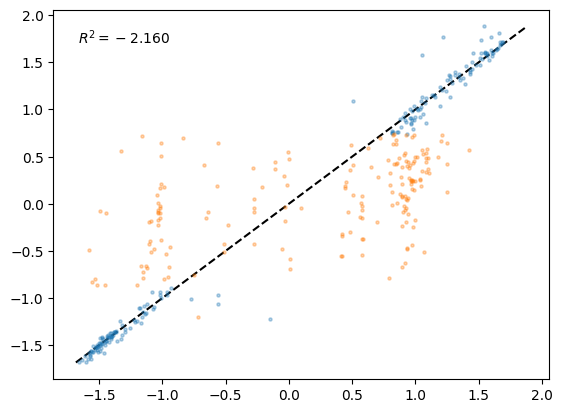

In [93]:
rf = RandomForestRegressor(random_state = 0)
_ = rf.fit(X_train, y_train.loc[:, main_task].values.flatten())

out_train = rf.predict(X_train)
out_test = rf.predict(X_test)

fig,ax = plt.subplots()
min_max = [op(y_train.values[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)

ax.scatter(out_train, y_train.values[:, 0], s=5, alpha=0.33)
ax.scatter(out_test, y_test.values[:, 0], s=5, alpha=0.33)

r2_test = r2_score(y_test.values[:, 0], out_test)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top') 

(array([ 1.,  4., 14., 16., 11., 30., 23., 29., 34., 23.]),
 array([-1.19449074, -1.00132612, -0.8081615 , -0.61499688, -0.42183226,
        -0.22866764, -0.03550302,  0.1576616 ,  0.35082623,  0.54399085,
         0.73715547]),
 <BarContainer object of 10 artists>)

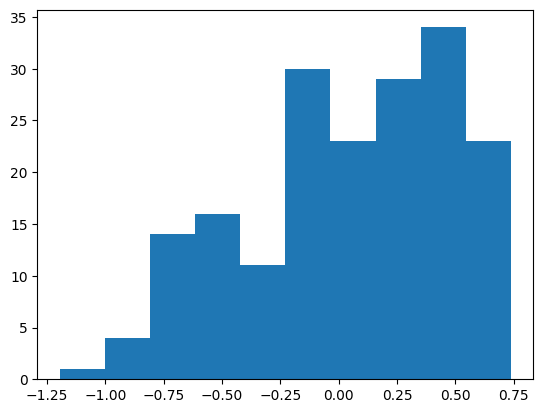

In [95]:
plt.hist(y_test.loc[:, main_task])

In [81]:
rf = RandomForestRegressor(random_state = 0)
is_finite = np.isfinite(y_train.values[:, 0]).flatten()
print(np.sum(is_finite))
_ = rf.fit(X_train.loc[is_finite], y_train.loc[is_finite][:, 0])

out_train = rf.predict(X_train)
out_test = rf.predict(X_test)
# 
fig,ax = plt.subplots()
min_max = [op(y_train.values[:, 0]) for op in (np.nanmin, np.nanmax)]
ax.plot(min_max, min_max, 'k--', zorder=0)
# 
r2_test = r2_score(y_test.values[:, 0], out_test)
ax.scatter(out_train, y_train.values[:, 0], s=5, alpha=0.33)
ax.scatter(out_test, y_test.values[:, 0], s=5, alpha=0.33)
ax.text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=ax.transAxes, ha='left', va='top')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2) 

185


InvalidIndexError: (slice(None, None, None), 0)

In [62]:
y_train[is_finite]

,HV,V0_Miedema,DFTv0,Nval
2,1.356160,0.441459,0.479143,-0.523952
3,1.154215,0.351637,0.419300,-0.406570
4,1.149825,0.321005,0.383467,-0.383093
5,0.947881,0.464490,0.476655,-0.641335
8,1.092754,0.020514,0.069561,-0.113406
...,...,...,...,...
361,1.716149,1.522084,1.471942,-1.920806
362,1.474693,1.511029,1.466756,-1.850376
363,1.562495,1.528533,1.477625,-1.967759
364,1.694198,1.807671,1.795615,-1.920806
